<a href="https://colab.research.google.com/github/kavisubramani2008-pixel/neural-network/blob/main/Neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)

n_students = 200

study_hours = np.random.randint(1, 11, n_students)
attendance = np.random.randint(50, 101, n_students)
previous_marks = np.random.randint(35, 96, n_students)
assignment_score = np.random.randint(30, 101, n_students)

score = (
    study_hours * 5
    + attendance * 0.25
    + previous_marks * 0.35
    + assignment_score * 0.25
)

result = (score >= 85).astype(int)

data = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "previous_marks": previous_marks,
    "assignment_score": assignment_score,
    "result": result
})

data.head()

,study_hours,attendance,previous_marks,assignment_score,result
0,7,71,88,59,1
1,4,60,77,46,0
2,8,97,94,91,1
3,5,65,71,42,0
4,7,82,67,88,1


In [ ]:
print("Dataset shape:", data.shape)
print()
print(data.head(10))
print()
print(data["result"].value_counts())

Dataset shape: (200, 5)

   study_hours  attendance  previous_marks  assignment_score  result
0            7          71              88                59       1
1            4          60              77                46       0
2            8          97              94                91       1
3            5          65              71                42       0
4            7          82              67                88       1
5           10          58              42                48       1
6            3          55              87                78       0
7            7          65              94                41       1
8            8          78              78                90       1
9            5          52              78                48       0

result
1    101
0     99
Name: count, dtype: int64


In [ ]:
data.to_csv("student_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
X = data[
    [
        "study_hours",
        "attendance",
        "previous_marks",
        "assignment_score"
    ]
].values

y = data["result"].values

In [ ]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

print(X[:5])

[[ 0.49784389 -0.3644814   1.23599824 -0.25128766]
 [-0.53933088 -1.13997373  0.60347995 -0.89119746]
 [ 0.84356881  1.46850049  1.58100822  1.32387494]
 [-0.19360596 -0.78747722  0.25846997 -1.08809279]
 [ 0.49784389  0.41101094  0.02846332  1.17620345]]


In [ ]:
np.random.seed(42)


W1 = np.random.randn(4, 5) * 0.1

b1 = np.zeros((1, 5))


W2 = np.random.randn(5, 1) * 0.1


b2 = np.zeros((1, 1))

print("W1:")
print(W1)

print("\nB1:")
print(b1)

print("\nW2:")
print(W2)

print("\nB2:")
print(b2)

W1:
[[ 0.04967142 -0.01382643  0.06476885  0.15230299 -0.02341534]
 [-0.0234137   0.15792128  0.07674347 -0.04694744  0.054256  ]
 [-0.04634177 -0.04657298  0.02419623 -0.19132802 -0.17249178]
 [-0.05622875 -0.10128311  0.03142473 -0.09080241 -0.14123037]]

B1:
[[0. 0. 0. 0. 0.]]

W2:
[[ 0.14656488]
 [-0.02257763]
 [ 0.00675282]
 [-0.14247482]
 [-0.05443827]]

B2:
[[0.]]


In [ ]:
def relu(x):
    return np.maximum(0, x)

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
def forward(X, W1, b1, W2, b2):

    Z1 = np.dot(X, W1) + b1

    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2

    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2

In [ ]:
Z1, A1, Z2, A2 = forward(
    X, W1, b1, W2, b2
)

print("Output shape:", A2.shape)
print("First 5 predictions:")
print(A2[:5])

Output shape: (200, 1)
First 5 predictions:
[[0.50004437]
 [0.5008078 ]
 [0.50034661]
 [0.49913697]
 [0.50017125]]


In [ ]:
def binary_cross_entropy(y, y_pred):

    epsilon = 1e-8

    loss = -np.mean(
        y * np.log(y_pred + epsilon)
        + (1 - y) * np.log(1 - y_pred + epsilon)
    )

    return loss

In [ ]:
loss = binary_cross_entropy(
    y.reshape(-1, 1),
    A2
)

print("Initial Loss:", loss)

Initial Loss: 0.6928109990026725


In [ ]:
learning_rate = 0.01
epochs = 2000

losses = []

In [ ]:
def backward(X, y, Z1, A1, A2, W2):

    m = len(X)

    y = y.reshape(-1, 1)

    dZ2 = A2 - y

    dW2 = np.dot(A1.T, dZ2) / m

    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * (Z1 > 0)

    dW1 = np.dot(X.T, dZ1) / m

    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

In [ ]:
dW1, db1, dW2, db2 = backward(
    X, y, Z1, A1, A2, W2
)

print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)
print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)

dW1 shape: (4, 5)
db1 shape: (1, 5)
dW2 shape: (5, 1)
db2 shape: (1, 1)


In [ ]:
W1 -= learning_rate * dW1
b1 -= learning_rate * db1

W2 -= learning_rate * dW2
b2 -= learning_rate * db2

In [ ]:
for epoch in range(epochs):

    # Forward propagation
    Z1, A1, Z2, A2 = forward(
        X, W1, b1, W2, b2
    )

    # Calculate loss
    loss = binary_cross_entropy(
        y.reshape(-1, 1),
        A2
    )

    losses.append(loss)

    # Backpropagation
    dW1, db1, dW2, db2 = backward(
        X, y, Z1, A1, A2, W2
    )

    # Gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # Display progress
    if epoch % 200 == 0:
        print(
            f"Epoch {epoch}, Loss: {loss:.4f}"
        )

Epoch 0, Loss: 0.6928
Epoch 200, Loss: 0.6869
Epoch 400, Loss: 0.6736
Epoch 600, Loss: 0.6399
Epoch 800, Loss: 0.5649
Epoch 1000, Loss: 0.4477
Epoch 1200, Loss: 0.3320
Epoch 1400, Loss: 0.2496
Epoch 1600, Loss: 0.1976
Epoch 1800, Loss: 0.1643


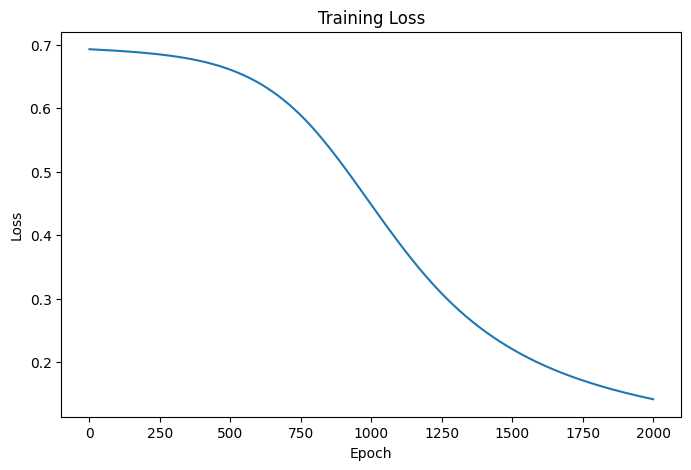

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

In [ ]:
_, _, _, predictions = forward(
    X, W1, b1, W2, b2
)

predicted_classes = (
    predictions >= 0.5
).astype(int)

accuracy = np.mean(
    predicted_classes.flatten() == y
)

print("Accuracy:", accuracy * 100, "%")

Accuracy: 99.0 %


In [ ]:
results = pd.DataFrame({
    "Actual": y,
    "Predicted": predicted_classes.flatten()
})

print(results.head(20))

    Actual  Predicted
0        1          1
1        0          0
2        1          1
3        0          0
4        1          1
5        1          1
6        0          0
7        1          1
8        1          1
9        0          0
10       0          0
11       1          1
12       0          0
13       0          0
14       0          0
15       1          1
16       0          0
17       1          1
18       1          1
19       0          0


In [ ]:
def predict_student(
    study_hours,
    attendance,
    previous_marks,
    assignment_score
):

    student = np.array([[
        study_hours,
        attendance,
        previous_marks,
        assignment_score
    ]], dtype=float)

    # Normalize using training data statistics
    student = (
        student - data[
            [
                "study_hours",
                "attendance",
                "previous_marks",
                "assignment_score"
            ]
        ].values.mean(axis=0)
    ) / data[
        [
            "study_hours",
            "attendance",
            "previous_marks",
            "assignment_score"
        ]
    ].values.std(axis=0)

    _, _, _, prediction = forward(
        student,
        W1,
        b1,
        W2,
        b2
    )

    probability = prediction[0][0]

    if probability >= 0.5:
        result = "PASS"
    else:
        result = "FAIL"

    print("Pass Probability:", probability)
    print("Prediction:", result)

In [ ]:
predict_student(
    study_hours=8,
    attendance=90,
    previous_marks=80,
    assignment_score=85
)

Pass Probability: 0.9932061561405525
Prediction: PASS


In [ ]:
predict_student(
    study_hours=2,
    attendance=55,
    previous_marks=40,
    assignment_score=45
)

Pass Probability: 0.003534002394981987
Prediction: FAIL
